# 42 — Face Explainability

Generates spatial attribution visualisations for both fine-tuned face models
(**ViT-B/16** and **MobileNetV3-Small**) using two complementary methods:

| Method | Architecture support | What it shows |
|---|---|---|
| **Grad-CAM** (pytorch-grad-cam) | ViT-B/16 (with reshape transform), MobileNetV3-Small | Spatially important regions via gradient-weighted feature maps |
| **Integrated Gradients** (Captum) | Both | Pixel-level attribution from a black-image baseline |

**Reads checkpoints from:** `../experiments/face_unimodal/v1/<model_slug>/model/`

**Writes plots to:** `../experiments/explainability/face/<model_slug>/`

---
*Requires:*
- `captum>=0.7.0`   — `pip install captum`
- `grad-cam>=1.5.0` — `pip install grad-cam`


In [22]:
import os, sys
import numpy as np
import torch
from PIL import Image

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, "src")) else os.path.abspath(os.path.join(_here, ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)

from src.config import (
    EXP_ROOT_FACE, EXP_ROOT_EXPLAIN, VERSION,
    FACE_MODELS_TO_RUN, FACE_USE_CACHE, FACE_CACHE_DIR, DEVICE,
)
from src.data.face_dataset import load_face_metadata, ID2LABEL, get_transforms, _cache_dir_path, _npy_filename
from src.evaluation.evaluate_face import _load_checkpoint
from src.training.utils import slugify
from src.explainability import FaceExplainer
from src.explainability.utils import (
    make_explain_dir, select_explanation_samples,
    plot_gradcam_overlay, plot_ig_face,
    denormalize_imagenet,
)

print("Device:", DEVICE)
print("Models:", FACE_MODELS_TO_RUN)

Device: cuda
Models: ['vit_b_16', 'mobilenet_v3_small']


## Load test metadata and checkpoints

In [23]:
test_df = load_face_metadata("test", version=VERSION)
print(f"Test frames      : {len(test_df)}")
print(f"Test utterances  : {test_df[['dialogue_id','utterance_id']].drop_duplicates().shape[0]}")

def load_face_explainer(model_name):
    slug    = slugify(model_name)
    run_dir = os.path.join(EXP_ROOT_FACE, VERSION, slug)
    assert os.path.isdir(run_dir), f"Run dir not found: {run_dir}"
    model = _load_checkpoint(run_dir, DEVICE)
    print(f"  Loaded {model_name}")
    return FaceExplainer(model, model_name, DEVICE)

explainers = {}
for mname in FACE_MODELS_TO_RUN:
    print(f"Loading {mname} …")
    explainers[mname] = load_face_explainer(mname)
print("All models loaded.")

Test frames      : 12117
Test utterances  : 2481
Loading vit_b_16 …
  Loaded vit_b_16
Loading mobilenet_v3_small …
  Loaded mobilenet_v3_small
All models loaded.


## Collect utterance-level predictions

For each utterance we average the softmax probabilities across its K=5 frames,
then apply argmax — consistent with how the models were evaluated.


In [24]:
from collections import defaultdict
from torch.utils.data import DataLoader
from src.data.face_dataset import FaceEmotionDataset

@torch.no_grad()
def get_face_test_preds(explainer, test_df):
    cdir = None
    if FACE_USE_CACHE:
        cdir = _cache_dir_path("test", VERSION, FACE_CACHE_DIR)
    ds = FaceEmotionDataset(
        df=test_df,
        transform=get_transforms(train=False),
        use_score_weights=False,
        use_cache=FACE_USE_CACHE,
        cache_dir=cdir,
    )
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    utt_probs  = defaultdict(list)
    utt_labels = {}
    for images, labels, _, d_ids, u_ids in loader:
        images = images.to(DEVICE)
        logits = explainer.model(images)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        for i in range(len(labels)):
            key = (int(d_ids[i]), int(u_ids[i]))
            utt_probs[key].append(probs[i])
            utt_labels[key] = int(labels[i])
    preds, lbls = [], []
    for key in utt_labels:
        avg_p = np.mean(utt_probs[key], axis=0)
        preds.append(int(avg_p.argmax()))
        lbls.append(utt_labels[key])
    return preds, lbls

# For sample selection we work at the frame level (test_df rows)
# and match by (dialogue_id, utterance_id)
model_utt_samples = {}
for mname, explainer in explainers.items():
    print(f"Inference: {mname} …")
    utt_preds, utt_labels = get_face_test_preds(explainer, test_df)
    acc = sum(p == l for p, l in zip(utt_preds, utt_labels)) / len(utt_labels)
    print(f"  Utterance accuracy: {acc:.4f}")
    samples = select_explanation_samples(utt_labels, utt_preds, ID2LABEL, n_correct=1, n_incorrect=1)
    model_utt_samples[mname] = {"preds": utt_preds, "labels": utt_labels, "samples": samples}
    print(f"  Selected {sum(len(v) for v in samples.values())} utterances")

Inference: vit_b_16 …
  Utterance accuracy: 0.3426
  Selected 14 utterances
Inference: mobilenet_v3_small …
  Utterance accuracy: 0.2398
  Selected 14 utterances


## Generate explanations

For each model and each selected utterance we pick its **highest-scoring
frame** (by FER score) and produce:

- A **Grad-CAM** overlay
- An **Integrated Gradients** overlay (magnitude + signed)

All images are saved to `experiments/explainability/face/<model_slug>/`.


In [25]:
IG_STEPS = 50
transform_eval = get_transforms(train=False)

def pick_best_frame(test_df, dia_id, utt_id):
    """Return the image_path of the frame with the highest score_comb for a given utterance."""
    rows = test_df[
        (test_df["dialogue_id"] == dia_id) & (test_df["utterance_id"] == utt_id)
    ]
    if rows.empty:
        return None
    if "score_comb" in rows.columns:
        row = rows.loc[rows["score_comb"].idxmax()]
    else:
        row = rows.iloc[0]
    return row["image_path"]

def load_frame_tensor(image_path):
    """Load a face crop PNG and apply eval transforms → (1, 3, 224, 224) tensor."""
    img = Image.open(image_path).convert("RGB")
    t   = transform_eval(img)          # (3, 224, 224)
    return t.unsqueeze(0)              # (1, 3, 224, 224)

# Build a (dia_id, utt_id) → utterance_index mapping for the utterance lists
# utt_labels list has the same order as unique (dia, utt) keys from get_face_test_preds

for mname, explainer in explainers.items():
    slug    = slugify(mname)
    out_dir = make_explain_dir("face", slug)
    samples = model_utt_samples[mname]["samples"]
    utt_preds  = model_utt_samples[mname]["preds"]
    utt_labels = model_utt_samples[mname]["labels"]

    print(f"\n=== {mname} → {out_dir} ===")

    for emotion, sample_list in samples.items():
        for utt_idx, is_correct in sample_list:
            true_label  = ID2LABEL[utt_labels[utt_idx]]
            pred_label  = ID2LABEL[utt_preds[utt_idx]]
            correctness = "correct" if is_correct else "wrong"

            # Recover the (dia_id, utt_id) pair — same iteration order as
            # get_face_test_preds which follows defaultdict insertion order
            unique_utts = (
                test_df[["dialogue_id","utterance_id"]]
                .drop_duplicates()
                .reset_index(drop=True)
            )
            dia_id = int(unique_utts.iloc[utt_idx]["dialogue_id"])
            utt_id = int(unique_utts.iloc[utt_idx]["utterance_id"])

            img_path = pick_best_frame(test_df, dia_id, utt_id)
            if img_path is None or not os.path.exists(img_path):
                print(f"  [{emotion}] image not found for dia{dia_id}_utt{utt_id} — skip")
                continue

            sample_tag = f"{emotion.lower()}_{correctness}_d{dia_id}u{utt_id}"
            print(f"  [{emotion}] {'✓' if is_correct else '✗'}  dia{dia_id}_utt{utt_id}")

            img_tensor = load_frame_tensor(img_path)   # (1, 3, 224, 224)
            img_np     = denormalize_imagenet(img_tensor.squeeze(0))   # (224, 224, 3) uint8

            # ── Grad-CAM ────────────────────────────────────────────────────
            cam_map, pred_cls = explainer.grad_cam(img_tensor)
            title_cam = (
                f"Grad-CAM  |  {mname}  |  True: {true_label}  Pred: {pred_label}"
            )
            plot_gradcam_overlay(
                img_np, cam_map, title_cam,
                save_path=os.path.join(out_dir, f"gradcam_{sample_tag}.png"),
            )

            # ── Integrated Gradients ─────────────────────────────────────────
            ig_mag, ig_sign, _ = explainer.integrated_gradients(
                img_tensor, target_class=pred_cls, n_steps=IG_STEPS
            )
            title_ig = (
                f"IG  |  {mname}  |  True: {true_label}  Pred: {pred_label}"
            )
            plot_ig_face(
                img_np, ig_mag, ig_sign, title_ig,
                save_path=os.path.join(out_dir, f"ig_{sample_tag}.png"),
            )

    print(f"  Saved to {out_dir}")

print("\nDone — all face explanations saved.")


=== vit_b_16 → ../experiments/explainability\face\vit_b_16 ===
  [Anger] ✓  dia168_utt16
  [Anger] ✗  dia112_utt6
  [Disgust] ✓  dia169_utt18
  [Disgust] ✗  dia52_utt1
  [Fear] ✓  dia95_utt17
  [Fear] ✗  dia105_utt1
  [Happiness] ✓  dia175_utt6
  [Happiness] ✗  dia125_utt0
  [Neutral] ✓  dia232_utt2
  [Neutral] ✗  dia64_utt5
  [Sadness] ✓  dia12_utt2
  [Sadness] ✗  dia100_utt6
  [Surprise] ✓  dia205_utt7
  [Surprise] ✗  dia182_utt7
  Saved to ../experiments/explainability\face\vit_b_16

=== mobilenet_v3_small → ../experiments/explainability\face\mobilenet_v3_small ===
  [Anger] ✓  dia160_utt3
  [Anger] ✗  dia72_utt6
  [Disgust] ✓  dia244_utt6
  [Disgust] ✗  dia52_utt1
  [Fear] ✓  dia245_utt4
  [Fear] ✗  dia17_utt17
  [Happiness] ✓  dia112_utt16
  [Happiness] ✗  dia51_utt1
  [Neutral] ✓  dia65_utt8
  [Neutral] ✗  dia68_utt6
  [Sadness] ✓  dia123_utt11
  [Sadness] ✗  dia173_utt8
  [Surprise] ✓  dia71_utt5
  [Surprise] ✗  dia129_utt1
  Saved to ../experiments/explainability\face\mobilene

## Quick sanity check

Display the first Grad-CAM figure inline.


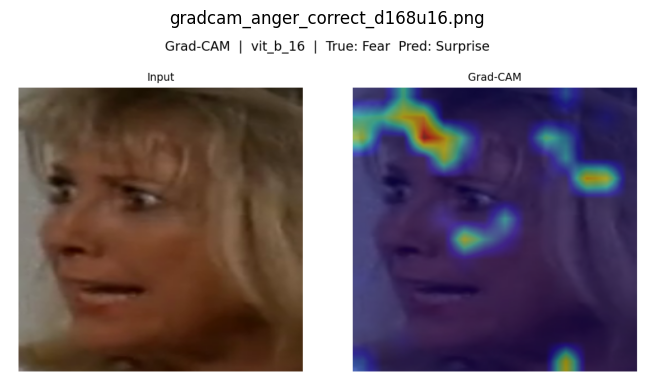

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for mname in FACE_MODELS_TO_RUN:
    slug    = slugify(mname)
    out_dir = os.path.join(EXP_ROOT_EXPLAIN, "face", slug)
    pngs    = sorted([f for f in os.listdir(out_dir) if f.startswith("gradcam_")])
    if pngs:
        img = mpimg.imread(os.path.join(out_dir, pngs[5]))
        plt.figure(figsize=(8, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(pngs[0])
        plt.tight_layout()
        plt.show()
        break